# Orbital dynamics: a guided tour
**Chloe Lin · UCL · 2025 project**

Can an orbit look plausible while its numerical solution is drifting? This short walkthrough reproduces a compact two-body benchmark and connects it to the original three-body investigations.

**Reading time:** about 5 minutes. **Data:** none required. **Scope:** the equations and methods from the coursework, condensed into a new demonstration; this does not rerun or validate every historical experiment.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Run from the repository root or its notebooks directory.
ROOT = Path.cwd() if (Path.cwd() / "README.md").exists() else Path.cwd().parent
(ROOT / "figures").mkdir(exist_ok=True)
plt.rcParams.update({"figure.facecolor":"#f8fafc", "axes.facecolor":"#f8fafc",
                     "axes.spines.top":False, "axes.spines.right":False, "font.size":11})

## 1. A benchmark with a known answer
Use a fixed central mass with $GM=1$, initial position $(1,0)$ and velocity $(0,1)$. The exact trajectory is a unit circle, with specific energy $-1/2$, angular momentum $1$, and period $2\pi$.

All three methods below use the same step size and duration. Euler is first order, velocity Verlet second order, and RK4 fourth order. Lower error in this short benchmark is not the same as superior long-term geometric behaviour.

In [2]:
def acceleration(r):
    """Central gravity in dimensionless units, GM = 1."""
    radius = np.linalg.norm(r)
    if radius <= 0:
        raise ValueError("Central collision: this demo has no collision model.")
    return -r / radius**3

def integrate(method, dt=0.02, duration=40.0):
    """Unit-radius circular initial orbit; state = [x, y, vx, vy]."""
    steps = round(duration / dt)
    state = np.zeros((steps + 1, 4))
    state[0] = [1, 0, 0, 1]
    def rhs(z):
        return np.r_[z[2:], acceleration(z[:2])]
    for i in range(steps):
        r, v = state[i, :2], state[i, 2:]
        if method == "Euler":
            state[i+1] = np.r_[r + dt*v, v + dt*acceleration(r)]
        elif method == "Velocity Verlet":
            a = acceleration(r)
            r_next = r + dt*v + 0.5*dt**2*a
            state[i+1] = np.r_[r_next, v + 0.5*dt*(a + acceleration(r_next))]
        elif method == "RK4":
            z = state[i]
            k1 = rhs(z)
            k2 = rhs(z + dt*k1/2)
            k3 = rhs(z + dt*k2/2)
            k4 = rhs(z + dt*k3)
            state[i+1] = z + dt*(k1 + 2*k2 + 2*k3 + k4)/6
        else:
            raise ValueError(f"Unknown method: {method}")
    return np.arange(steps + 1)*dt, state

def diagnostics(state):
    """Specific energy and z angular momentum (per unit orbiting mass)."""
    r, v = state[:, :2], state[:, 2:]
    energy = 0.5*np.sum(v*v, axis=1) - 1/np.linalg.norm(r, axis=1)
    angular = r[:,0]*v[:,1] - r[:,1]*v[:,0]
    return energy, angular

## 2. Compare the orbit and energy error
The horizontal axis uses the actual timestep for each computed sample. The logarithmic panel makes small energy errors visible.

Euler            max relative energy error=4.446e-01; max angular-momentum drift=3.402e-01
Velocity Verlet  max relative energy error=3.998e-08; max angular-momentum drift=2.109e-15
RK4              max relative energy error=3.556e-09; max angular-momentum drift=1.778e-09


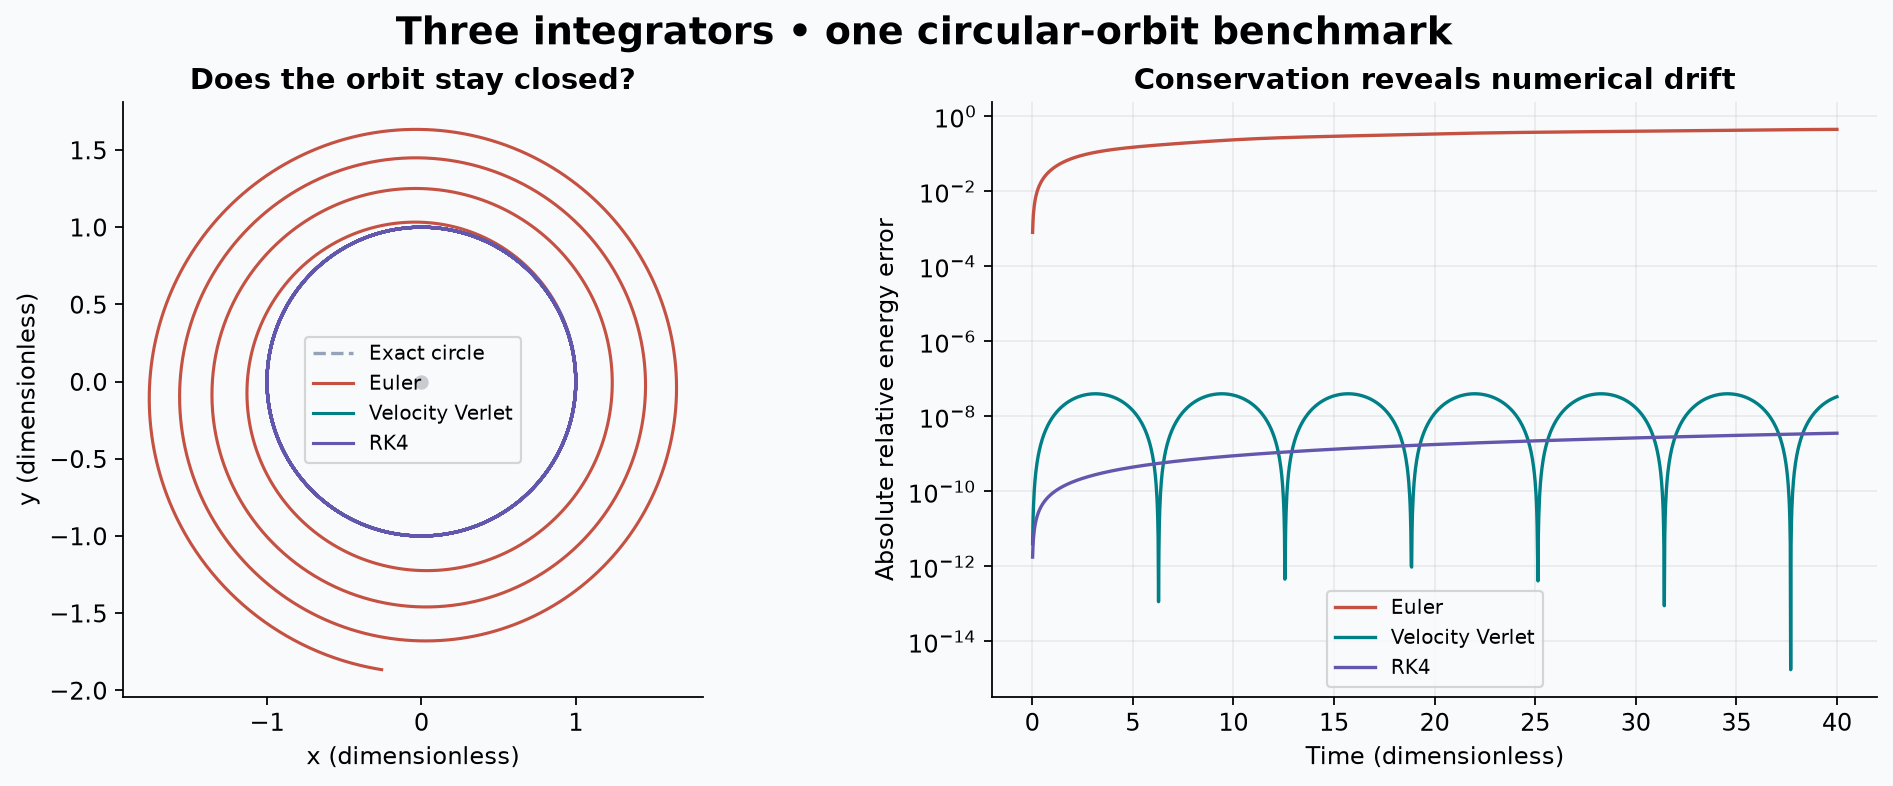

In [3]:
methods = ["Euler", "Velocity Verlet", "RK4"]
colours = ["#c45142", "#007f86", "#6356ad"]
results = {method: integrate(method) for method in methods}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
theta = np.linspace(0, 2*np.pi, 300)
axes[0].plot(np.cos(theta), np.sin(theta), "--", color="#94a3b8", label="Exact circle")
for method, colour in zip(methods, colours):
    t, state = results[method]
    energy, angular = diagnostics(state)
    axes[0].plot(state[:,0], state[:,1], color=colour, label=method, lw=1.4)
    error = np.abs((energy-energy[0])/energy[0])
    axes[1].plot(t[1:], np.maximum(error[1:], 1e-16), color=colour, label=method)
axes[0].scatter([0],[0],color="#0f172a",s=30)
axes[0].set(xlabel="x (dimensionless)",ylabel="y (dimensionless)",title="Does the orbit stay closed?")
axes[0].set_aspect("equal"); axes[0].legend(fontsize=9)
axes[1].set(xlabel="Time (dimensionless)",ylabel="Absolute relative energy error",yscale="log",title="Conservation reveals numerical drift")
axes[1].grid(alpha=0.2); axes[1].legend(fontsize=9)
fig.suptitle("Three integrators • one circular-orbit benchmark",fontsize=17,fontweight="bold")
fig.savefig(ROOT / "figures/integrator_comparison.png",dpi=160,bbox_inches="tight")
for method in methods:
    _, state = results[method]
    energy, angular = diagnostics(state)
    print(f"{method:16} max relative energy error={np.max(np.abs((energy-energy[0])/energy[0])):.3e}; max angular-momentum drift={np.max(np.abs(angular-angular[0])):.3e}")

## 3. Interpret and check
Euler accumulates substantial energy error. Verlet retains bounded energy oscillations in this example. RK4 is particularly accurate here at this timestep and duration; the plot does not establish that Verlet always outperforms RK4.

Check the known circular orbit at two step sizes and angular-momentum conservation. These checks concern this smooth benchmark, not close encounters.

In [4]:
# Independent analytic reference: one circular orbit has period 2*pi.
errors = []
for n in (160, 320):
    _, state = integrate("Velocity Verlet", dt=2*np.pi/n, duration=2*np.pi)
    errors.append(np.linalg.norm(state[-1,:2] - np.array([1.,0.])))
assert errors[1] < errors[0]/3, "Expected second-order convergence in this smooth benchmark"
assert np.max(np.abs(diagnostics(results["Velocity Verlet"][1])[1]-1)) < 1e-10
print("Circular-orbit convergence and angular-momentum checks passed.")
print("Position error at one orbit:", errors)

Circular-orbit convergence and angular-momentum checks passed.
Position error at one orbit: [np.float64(0.003227926357416601), np.float64(0.0008073365140662008)]


## 4. Continue to the three-body investigations
- [Logbook 1](logbooks/orbital_dynamics_logbook_1.ipynb): comparable-mass binaries and a star-planet-moon system.
- [Logbook 2](logbooks/orbital_dynamics_logbook_2.ipynb): Lagrange configurations, a simplified Alpha Centauri simulation over 500 simulated years, and 27 third-star parameter combinations.

Those logbooks retain their historical outputs. Close encounters need timestep-convergence checks before an ejection is interpreted physically. Finite runs are not proofs of general stability, and Alpha Centauri is a simplified model.

The original references and development history remain in the logbooks. This guided presentation was added during portfolio preparation.